In [1]:
import json
import os
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
from tqdm import tqdm

import supervision as sv
from rfdetr import RFDETRBase
from supervision.metrics import MeanAveragePrecision

In [15]:
DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"          # Root dir containing test/
BASELINE_WEIGHTS  = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models\\checkpoint_best_total.pth"
SIMPLE_CKA_WEIGHTS = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_loss_output\\checkpoint_best_total.pth"
MULTILAYER_CKA_WEIGHTS = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\checkpoint_best_total.pth"

BASELINE_LOG  = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\trained_models\\log.txt"
MULTILAYER_LOG = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\log.txt"

CONFIDENCE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


# UTILITY FUNCTIONS

In [4]:
def compute_iou_matrix(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    """Return an (N, M) IoU matrix for two sets of xyxy boxes."""
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))

    x1_1, y1_1, x2_1, y2_1 = [boxes1[:, i][:, None] for i in range(4)]
    x1_2, y1_2, x2_2, y2_2 = [boxes2[:, i][None, :] for i in range(4)]

    inter = (np.maximum(0, np.minimum(x2_1, x2_2) - np.maximum(x1_1, x1_2)) *
             np.maximum(0, np.minimum(y2_1, y2_2) - np.maximum(y1_1, y1_2)))
    union = (x2_1 - x1_1) * (y2_1 - y1_1) + (x2_2 - x1_2) * (y2_2 - y1_2) - inter
    return inter / (union + 1e-6)


def check_detection(gt_box: np.ndarray, pred_boxes: np.ndarray,
                    iou_threshold: float = IOU_THRESHOLD):
    """Return (detected: bool, max_iou: float) for a single GT box."""
    if len(pred_boxes) == 0:
        return False, 0.0
    ious = compute_iou_matrix(gt_box[None, :], pred_boxes)[0]
    max_iou = ious.max()
    return max_iou >= iou_threshold, float(max_iou)


def compute_box_area(box: np.ndarray) -> float:
    """Return pixel area of an xyxy bounding box."""
    return float((box[2] - box[0]) * (box[3] - box[1]))

# MODEL LOADING

In [19]:
def _load_model(weights_path: str, label: str) -> RFDETRBase:
    model = RFDETRBase(pretrain_weights=weights_path)
    model.optimize_for_inference()
    print(f"  ✓ {label}")
    return model

print("Loading models …")
model_baseline       = _load_model(BASELINE_WEIGHTS,       "Baseline RF-DETR")
model_simple_cka     = _load_model(SIMPLE_CKA_WEIGHTS,     "Simple CKA RF-DETR")
model_multilayer_cka = _load_model(MULTILAYER_CKA_WEIGHTS, "Multi-layer CKA RF-DETR")
print("\nAll models loaded and optimised for inference.")

Loading models …
Loading pretrain weights


  ✓ Baseline RF-DETR
Loading pretrain weights
  ✓ Simple CKA RF-DETR
Loading pretrain weights
  ✓ Multi-layer CKA RF-DETR

All models loaded and optimised for inference.


In [20]:
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

with open(f"{DATASET_DIR}/test/_annotations.coco.json") as f:
    coco_data = json.load(f)

class_names = {cat["id"]: cat["name"] for cat in coco_data["categories"]}

print(f"✓ Test set loaded: {len(ds)} images")
print(f"✓ Classes: {class_names}")

✓ Test set loaded: 63 images
✓ Classes: {0: 'fish', 1: 'jellyfish', 2: 'penguin', 3: 'puffer_fish', 4: 'shark', 5: 'stingray', 6: 'starfish'}


# MAP EVALUATION


In [21]:
def _run_inference(model, label: str):
    targets, preds = [], []
    for path, _, annotations in tqdm(ds, desc=label):
        preds.append(model.predict(Image.open(path).convert("RGB"), threshold=0))
        targets.append(annotations)
    return targets, preds

def _compute_map(predictions, targets):
    metric = MeanAveragePrecision()
    metric.update(predictions, targets)
    return metric.compute()

print("Running inference — this may take a few minutes …\n")
targets,   preds_b = _run_inference(model_baseline,       "Baseline")
_,         preds_s = _run_inference(model_simple_cka,     "Simple CKA")
_,         preds_m = _run_inference(model_multilayer_cka, "Multi-layer CKA")

print("\nComputing mAP …")
r_b = _compute_map(preds_b, targets)
r_s = _compute_map(preds_s, targets)
r_m = _compute_map(preds_m, targets)

Running inference — this may take a few minutes …



Multi-layer CKA: 100%|██████████| 63/63 [00:33<00:00,  1.88it/s]



Computing mAP …


In [22]:
metrics = ["mAP@0.5:0.95", "mAP@0.5", "mAP@0.75"]
vals_b  = [r_b.map50_95, r_b.map50, r_b.map75]
vals_s  = [r_s.map50_95, r_s.map50, r_s.map75]
vals_m  = [r_m.map50_95, r_m.map50, r_m.map75]

df_map = pd.DataFrame({
    "Metric":            metrics,
    "Baseline":          vals_b,
    "Simple CKA":        vals_s,
    "Multi-layer CKA":   vals_m,
    "Δ Simple CKA":      [s - b for s, b in zip(vals_s, vals_b)],
    "Δ Multi-layer CKA": [m - b for m, b in zip(vals_m, vals_b)],
})

print("\n" + "=" * 65)
print("mAP RESULTS")
print("=" * 65)
print(df_map.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

df_map.to_csv(OUTPUT_DIR / "map_comparison.csv", index=False)
print(f"\n✓ Saved → {OUTPUT_DIR / 'map_comparison.csv'}")


mAP RESULTS
      Metric  Baseline  Simple CKA  Multi-layer CKA  Δ Simple CKA  Δ Multi-layer CKA
mAP@0.5:0.95    0.5464      0.5488           0.5314        0.0024            -0.0150
     mAP@0.5    0.8393      0.8655           0.8426        0.0262             0.0033
    mAP@0.75    0.5860      0.5934           0.5708        0.0074            -0.0152

✓ Saved → output\map_comparison.csv


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(len(metrics)), 0.25
for i, (label, vals, colour) in enumerate([
    ("Baseline",        vals_b, "#3498db"),
    ("Simple CKA",      vals_s, "#e67e22"),
    ("Multi-layer CKA", vals_m, "#2ecc71"),
]):
    bars = ax.bar(x + i * w, vals, w, label=label, color=colour)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_xticks(x + w); ax.set_xticklabels(metrics)
ax.set_ylabel("Score"); ax.set_ylim(0, max(vals_b + vals_s + vals_m) * 1.15)
ax.set_title("mAP Comparison — Baseline vs CKA Variants", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "map_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Chart saved → {OUTPUT_DIR / 'map_comparison.png'}")

# Statistical Significance


In [23]:
def _detection_ratio(preds, tgts):
    return np.array([
        len(p.class_id) / max(len(t.class_id), 1)
        for p, t in zip(preds, tgts)
    ])

t_stat, p_val = stats.ttest_rel(
    _detection_ratio(preds_m, targets),
    _detection_ratio(preds_b, targets),
)

print("Paired t-test: Multi-layer CKA vs Baseline")
print(f"  t = {t_stat:.4f}")
print(f"  p = {p_val:.4f}")
print(f"  → {'✓ Statistically significant (p < 0.05)' if p_val < 0.05 else '⚠ Not significant (p ≥ 0.05)'}")

Paired t-test: Multi-layer CKA vs Baseline
  t = nan
  p = nan
  → ⚠ Not significant (p ≥ 0.05)


# Detection Pattern Analysis

In [24]:
pattern_both, pattern_simple, pattern_multi, pattern_better = [], [], [], []

for idx, (path, _, annotations) in enumerate(tqdm(ds, desc="Pattern analysis")):
    image_pil = Image.open(path).convert("RGB")
    pred_b = model_baseline.predict(image_pil,       threshold=CONFIDENCE_THRESHOLD)
    pred_s = model_simple_cka.predict(image_pil,     threshold=CONFIDENCE_THRESHOLD)
    pred_m = model_multilayer_cka.predict(image_pil, threshold=CONFIDENCE_THRESHOLD)

    for gt_box, gt_cls in zip(annotations.xyxy, annotations.class_id):
        b_det, b_iou = check_detection(gt_box, pred_b.xyxy)
        s_det, s_iou = check_detection(gt_box, pred_s.xyxy)
        m_det, m_iou = check_detection(gt_box, pred_m.xyxy)

        case = dict(
            image_idx=idx, image_path=path,
            gt_box=gt_box, gt_class=int(gt_cls),
            gt_class_name=class_names.get(int(gt_cls), "unknown"),
            box_area=compute_box_area(gt_box),
            baseline_det=b_det, baseline_iou=b_iou,
            simple_det=s_det,   simple_iou=s_iou,
            multi_det=m_det,    multi_iou=m_iou,
            pred_baseline=pred_b, pred_simple=pred_s, pred_multi=pred_m,
            gt_annotations=annotations,
        )

        if   not b_det and s_det and m_det:
            pattern_both.append(case)
        elif not b_det and s_det and not m_det:
            pattern_simple.append(case)
        elif not b_det and not s_det and m_det:
            pattern_multi.append(case)
        elif b_det and s_det and m_det and m_iou > b_iou + 0.10 and m_iou > s_iou + 0.05:
            pattern_better.append(case)


Pattern analysis: 100%|██████████| 63/63 [01:50<00:00,  1.76s/it]


In [25]:
summary = {
    "Both CKA detect (baseline misses)": len(pattern_both),
    "Only Simple CKA detects":           len(pattern_simple),
    "Only Multi-layer CKA detects":      len(pattern_multi),
    "Multi-layer has best localisation": len(pattern_better),
}
print("\nDetection Pattern Summary")
print("-" * 45)
for label, count in summary.items():
    print(f"  {label:<38}: {count}")


Detection Pattern Summary
---------------------------------------------
  Both CKA detect (baseline misses)     : 30
  Only Simple CKA detects               : 11
  Only Multi-layer CKA detects          : 11
  Multi-layer has best localisation     : 0


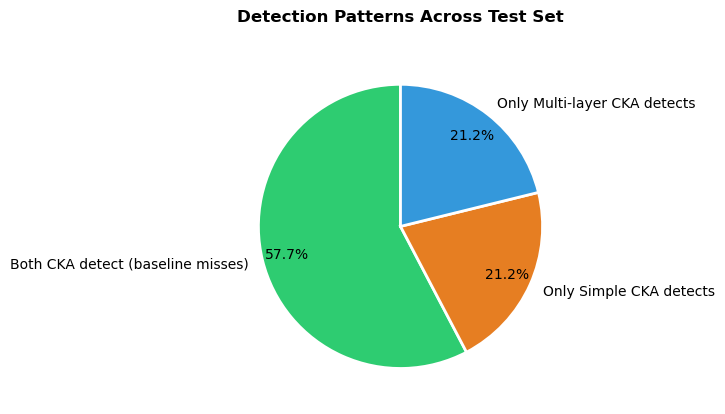

✓ Chart saved → output\detection_patterns.png


In [26]:
fig, ax = plt.subplots(figsize=(7, 7))
non_zero = {k: v for k, v in summary.items() if v > 0}
ax.pie(
    non_zero.values(),
    labels=non_zero.keys(),
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e67e22", "#3498db", "#9b59b6"],
    startangle=90, pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
ax.set_title("Detection Patterns Across Test Set", fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "detection_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Chart saved → {OUTPUT_DIR / 'detection_patterns.png'}")


# Select Best Examples Per Pattern

In [27]:
def _sort_key(case):
    """Smaller objects with higher IoU are more illustrative examples."""
    best_iou = max(case.get("simple_iou", 0), case.get("multi_iou", 0))
    return (case["box_area"], -best_iou)

selected_examples = []
for cases, label, desc in [
    (pattern_both,   "Both CKA Detect",      "baseline missed; both CKA variants detected"),
    (pattern_multi,  "Multi-layer CKA Only",  "only multi-layer CKA detected"),
    (pattern_simple, "Simple CKA Only",       "only simple CKA detected"),
]:
    if cases:
        best = sorted(cases, key=_sort_key)[0]
        best["pattern"] = label
        best["pattern_description"] = desc
        selected_examples.append(best)
        if len(selected_examples) == 3:
            break

print(f"Selected {len(selected_examples)} representative examples:\n")
for i, case in enumerate(selected_examples, 1):
    print(f"  Example {i}: {case['pattern']}")
    print(f"    Image idx : {case['image_idx']}  |  Class: {case['gt_class_name']}")
    print(f"    Area      : {case['box_area']:.0f} px²")
    print(f"    Baseline      {'✓' if case['baseline_det'] else '✗'}  IoU {case['baseline_iou']:.3f}")
    print(f"    Simple CKA    {'✓' if case['simple_det']   else '✗'}  IoU {case['simple_iou']:.3f}")
    print(f"    Multi-layer   {'✓' if case['multi_det']    else '✗'}  IoU {case['multi_iou']:.3f}\n")


Selected 3 representative examples:

  Example 1: Both CKA Detect
    Image idx : 48  |  Class: fish
    Area      : 210 px²
    Baseline      ✗  IoU 0.000
    Simple CKA    ✓  IoU 0.684
    Multi-layer   ✓  IoU 0.669

  Example 2: Multi-layer CKA Only
    Image idx : 40  |  Class: penguin
    Area      : 560 px²
    Baseline      ✗  IoU 0.034
    Simple CKA    ✗  IoU 0.056
    Multi-layer   ✓  IoU 0.542

  Example 3: Simple CKA Only
    Image idx : 40  |  Class: penguin
    Area      : 945 px²
    Baseline      ✗  IoU 0.000
    Simple CKA    ✓  IoU 0.506
    Multi-layer   ✗  IoU 0.173



# Example 1

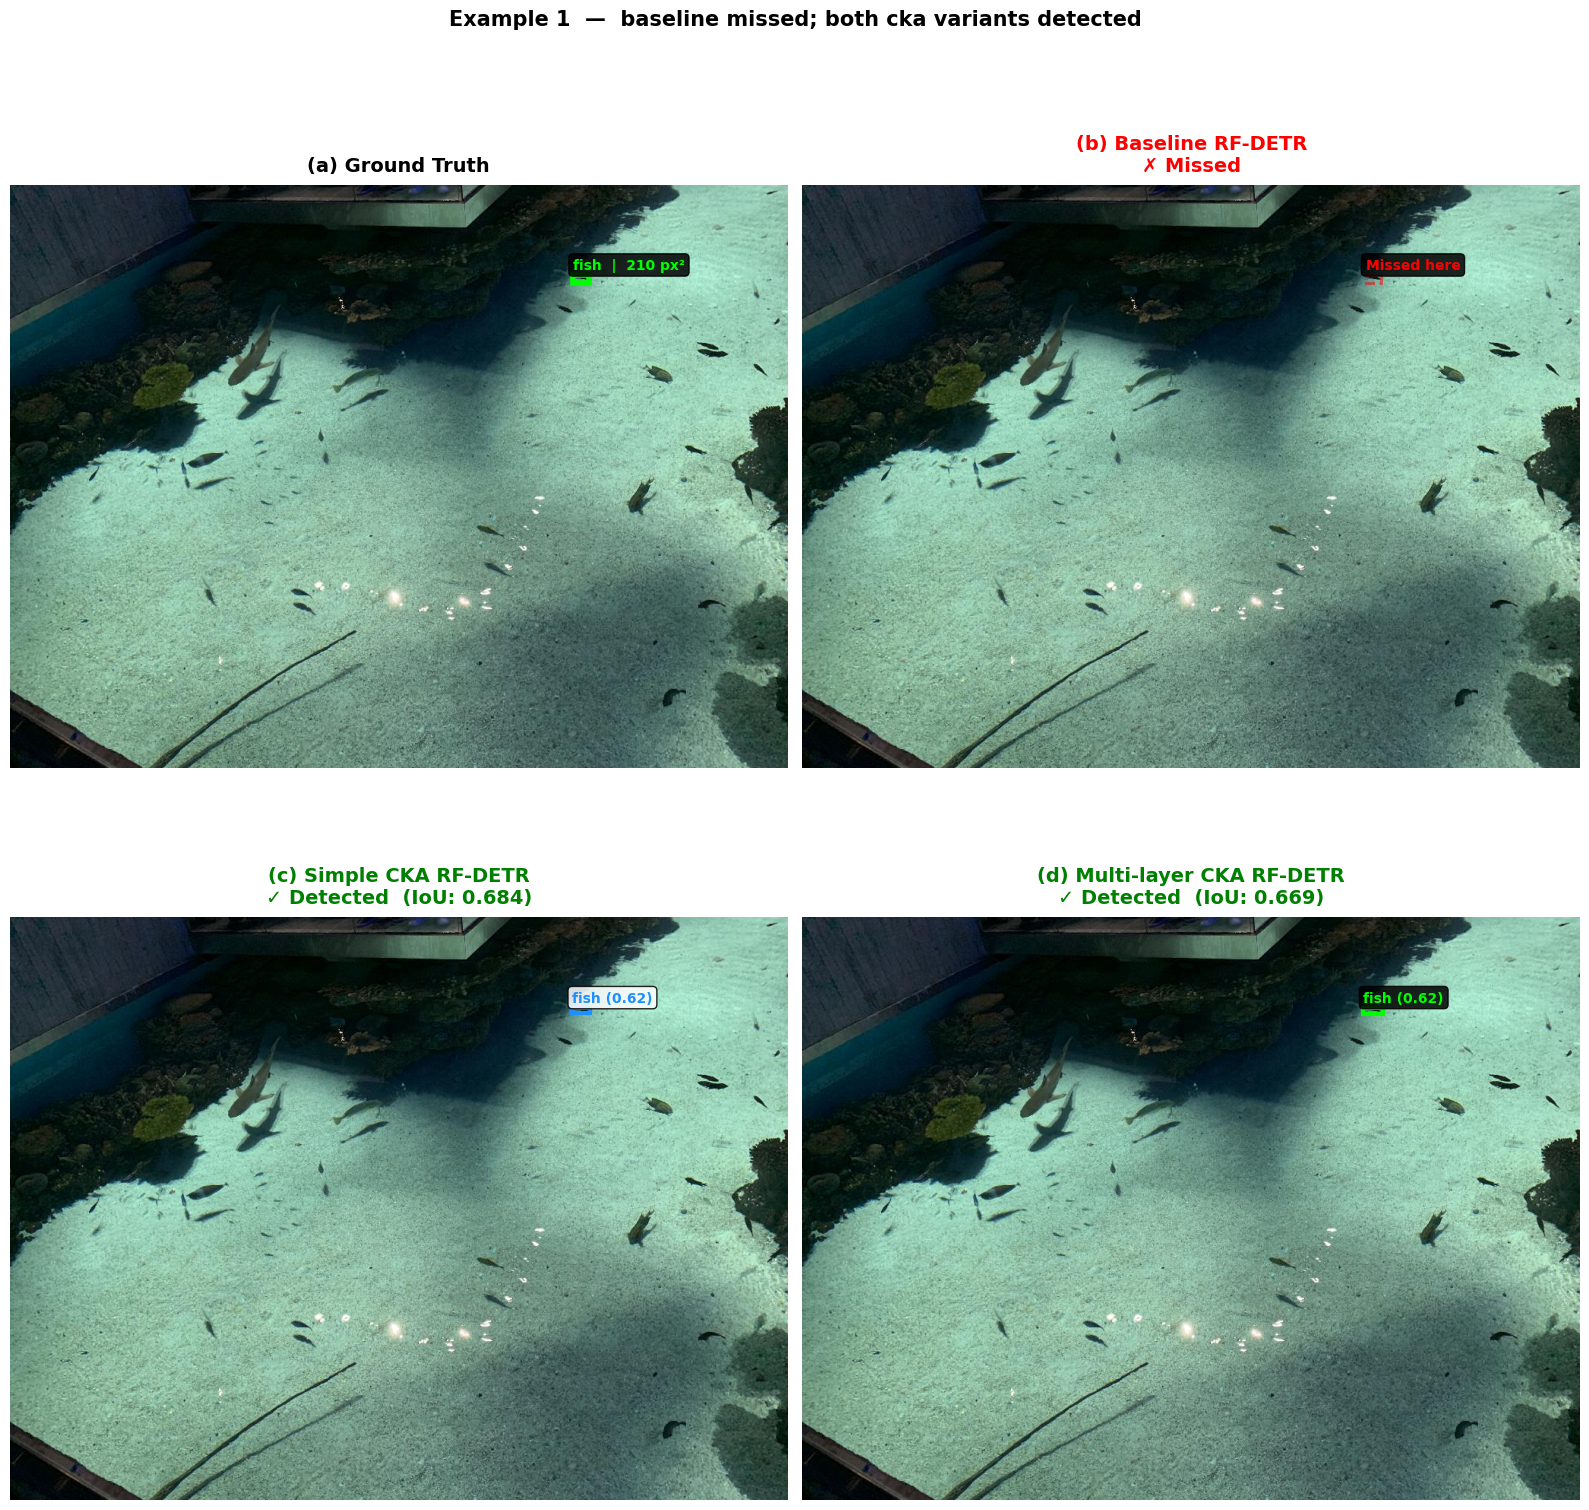

✓ Saved → output\example_1_both_cka_detect.png


In [28]:
def _draw_box(ax, box, colour, linewidth=2, linestyle="-", alpha=1.0, label=None, bg="white"):
    x1, y1, x2, y2 = box
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=linewidth, edgecolor=colour, facecolor="none",
        linestyle=linestyle, alpha=alpha,
    ))
    if label:
        ax.text(x1, y1 - 8, label, color=colour, fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round", facecolor=bg, alpha=0.85))


def create_comparison_figure(case: dict, title_prefix: str = "") -> plt.Figure:
    """4-panel figure: GT | Baseline | Simple CKA | Multi-layer CKA."""
    image_np = np.array(Image.open(case["image_path"]).convert("RGB"))
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()
    fs = 14

    # ── (a) Ground Truth ──────────────────────────────────────────────────────
    ax = axes[0]
    ax.imshow(image_np); ax.axis("off")
    ax.set_title("(a) Ground Truth", fontsize=fs, fontweight="bold", pad=10)
    _draw_box(ax, case["gt_box"], "lime", linewidth=4,
              label=f"{case['gt_class_name']}  |  {case['box_area']:.0f} px²",
              bg="black")

    # ── Panels (b–d) ──────────────────────────────────────────────────────────
    panel_cfg = [
        ("(b) Baseline RF-DETR",       "baseline_det", "baseline_iou", "pred_baseline", "green", "red"),
        ("(c) Simple CKA RF-DETR",     "simple_det",   "simple_iou",   "pred_simple",   "dodgerblue", "darkorange"),
        ("(d) Multi-layer CKA RF-DETR","multi_det",     "multi_iou",    "pred_multi",    "lime", "red"),
    ]

    for ax, (title_base, det_key, iou_key, pred_key, hit_col, miss_col) in zip(axes[1:], panel_cfg):
        ax.imshow(image_np); ax.axis("off")
        detected = case[det_key]
        iou      = case[iou_key]
        status   = f"✓ Detected  (IoU: {iou:.3f})" if detected else "✗ Missed"
        ax.set_title(f"{title_base}\n{status}",
                     fontsize=fs, fontweight="bold",
                     color="green" if detected else miss_col, pad=10)

        preds = case[pred_key]
        if detected and len(preds.xyxy) > 0:
            ious = compute_iou_matrix(case["gt_box"][None, :], preds.xyxy)[0]
            best = int(ious.argmax())
            box  = preds.xyxy[best]
            conf = preds.confidence[best]
            cls  = preds.class_id[best]
            _draw_box(ax, box, hit_col, linewidth=3,
                      label=f"{class_names.get(int(cls), '')} ({conf:.2f})",
                      bg="black" if hit_col == "lime" else "white")
        else:
            _draw_box(ax, case["gt_box"], miss_col, linewidth=2,
                      linestyle="--", alpha=0.55,
                      label="Missed here", bg="black")

    sup = f"{title_prefix}  —  {case['pattern_description']}" if title_prefix else case["pattern_description"]
    fig.suptitle(sup.capitalize(), fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig


if selected_examples:
    case = selected_examples[0]
    fig  = create_comparison_figure(case, title_prefix="Example 1")
    path = OUTPUT_DIR / f"example_1_{case['pattern'].replace(' ', '_').lower()}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ Saved → {path}")
else:
    print("No example available for this pattern.")


# Example 2

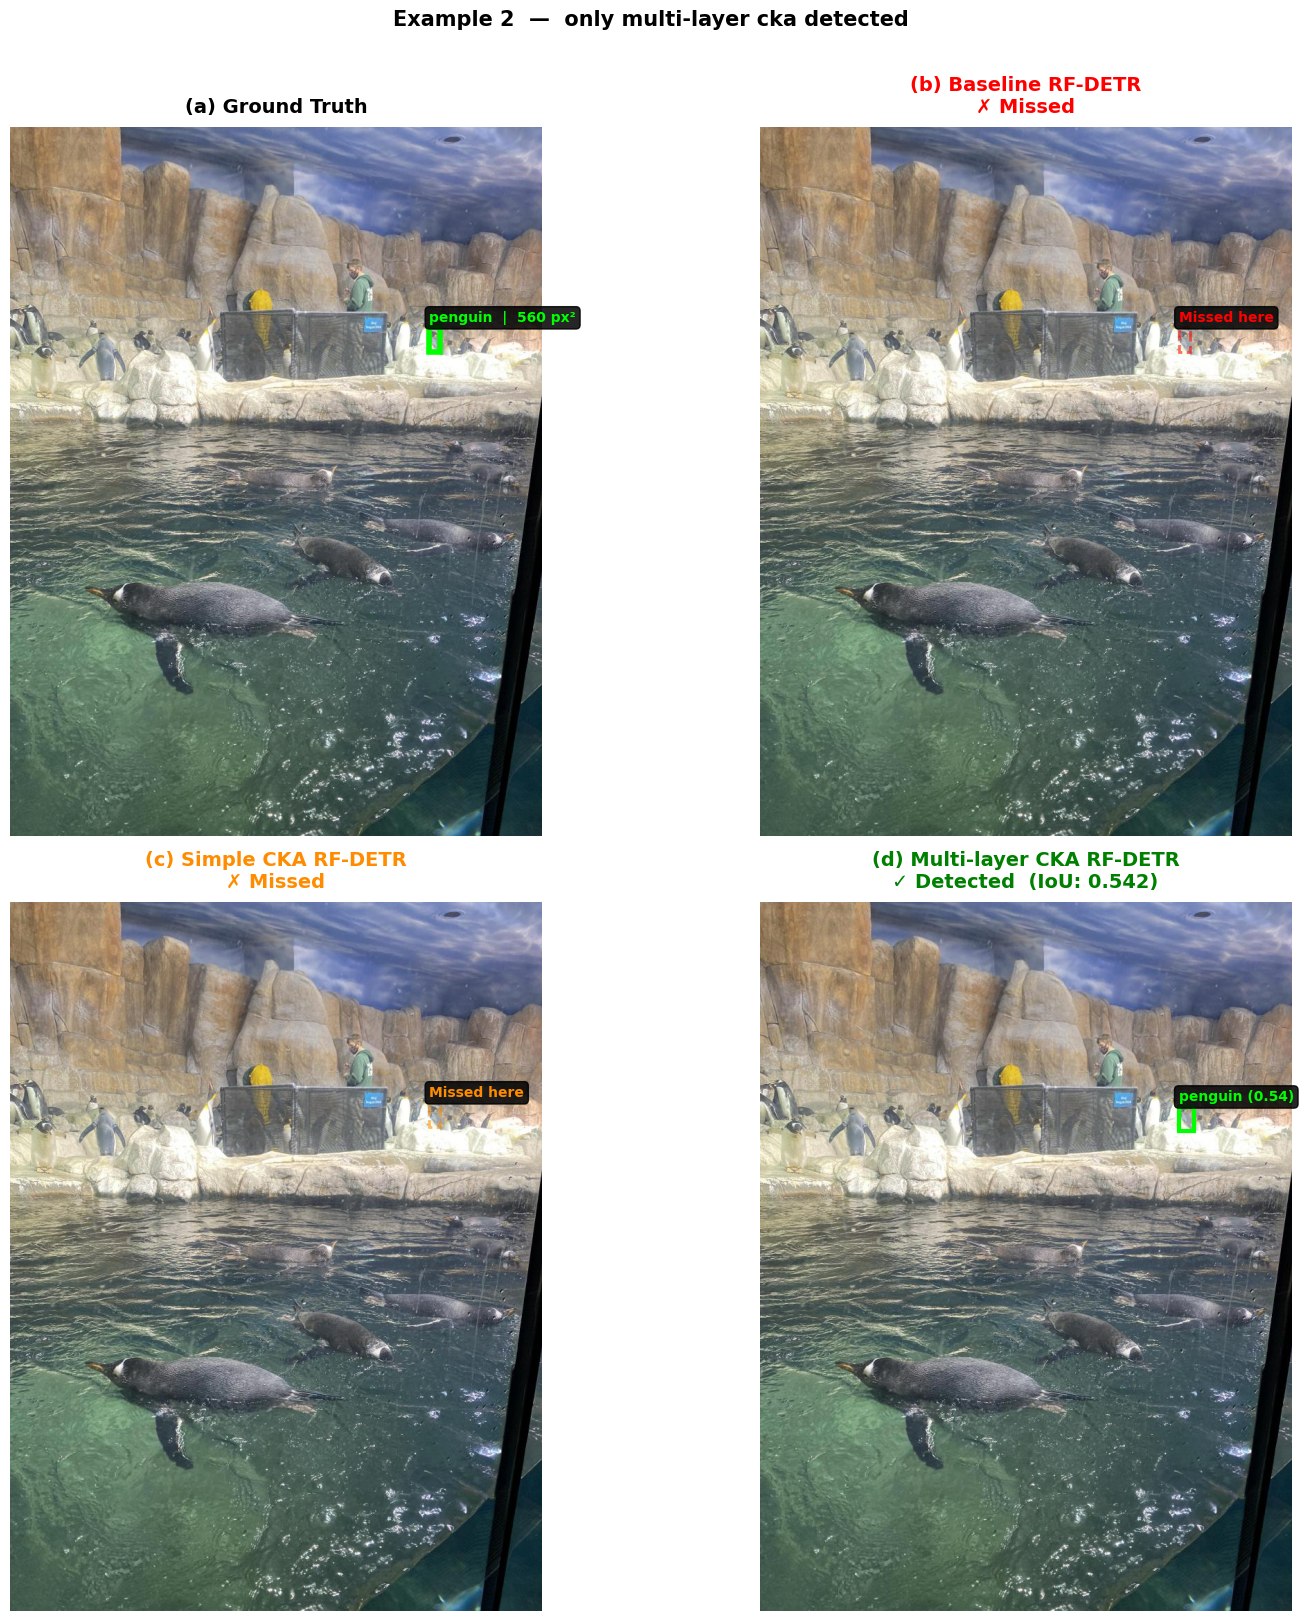

✓ Saved → output\example_2_multi-layer_cka_only.png


In [29]:
if len(selected_examples) > 1:
    case = selected_examples[1]
    fig  = create_comparison_figure(case, title_prefix="Example 2")
    path = OUTPUT_DIR / f"example_2_{case['pattern'].replace(' ', '_').lower()}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ Saved → {path}")
else:
    print("No second example available.")

# Example 3

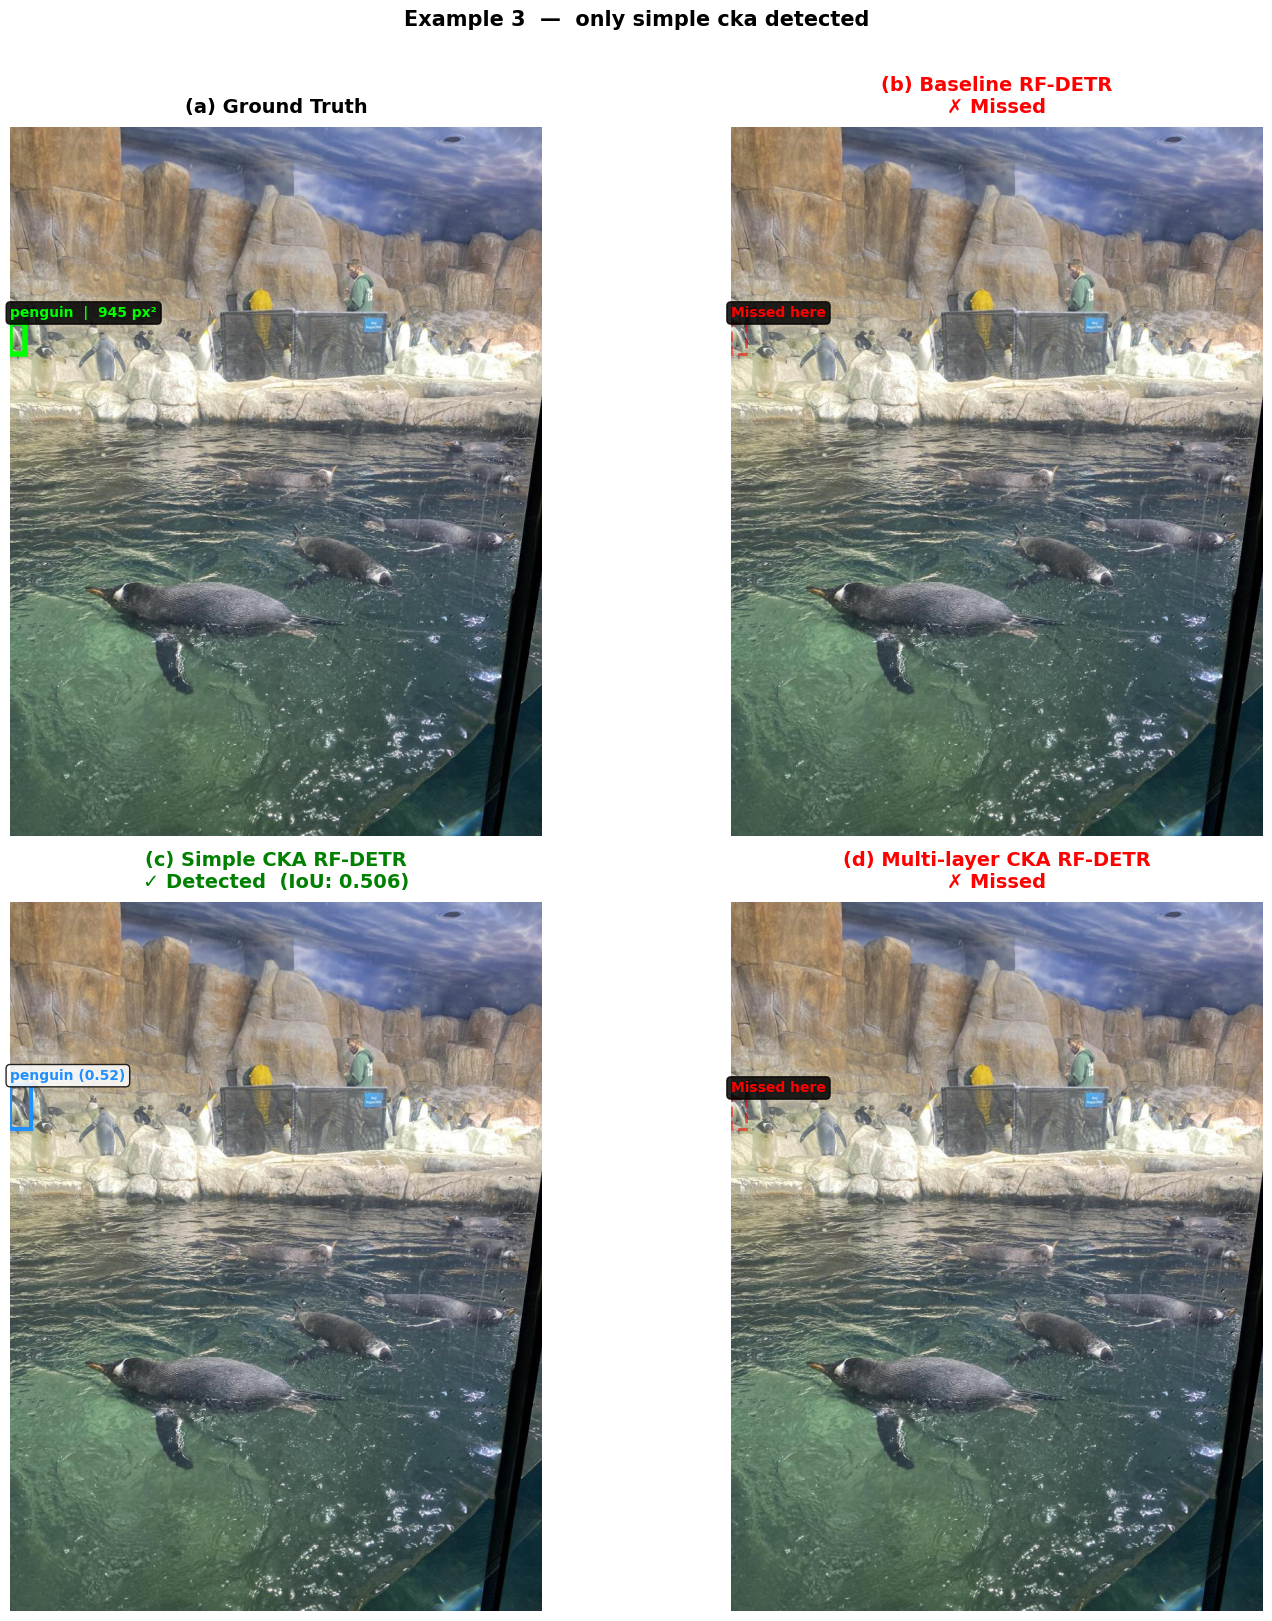

✓ Saved → output\example_3_simple_cka_only.png


In [30]:
if len(selected_examples) > 2:
    case = selected_examples[2]
    fig  = create_comparison_figure(case, title_prefix="Example 3")
    path = OUTPUT_DIR / f"example_3_{case['pattern'].replace(' ', '_').lower()}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ Saved → {path}")
else:
    print("No third example available.")

# TRAINING CURVE ANALYSIS

In [31]:
def parse_log(log_path: str) -> dict:
    """Parse an RF-DETR log file into metric arrays."""
    keys = ["epoch", "train_loss", "test_loss",
            "train_loss_ce_unscaled", "train_loss_bbox_unscaled",
            "train_loss_giou_unscaled"]
    data = {k: [] for k in keys}
    data.update({"test_coco_map": [], "test_coco_map50": []})

    with open(log_path) as f:
        for line in f:
            try:
                row = json.loads(line.strip())
            except json.JSONDecodeError:
                continue
            for k in keys:
                data[k].append(row.get(k, 0))
            coco = row.get("test_coco_eval_bbox", [0, 0])
            data["test_coco_map"].append(coco[0] if coco else 0)
            data["test_coco_map50"].append(coco[1] if len(coco) > 1 else 0)
    return data

log_b = parse_log(BASELINE_LOG)
log_m = parse_log(MULTILAYER_LOG)

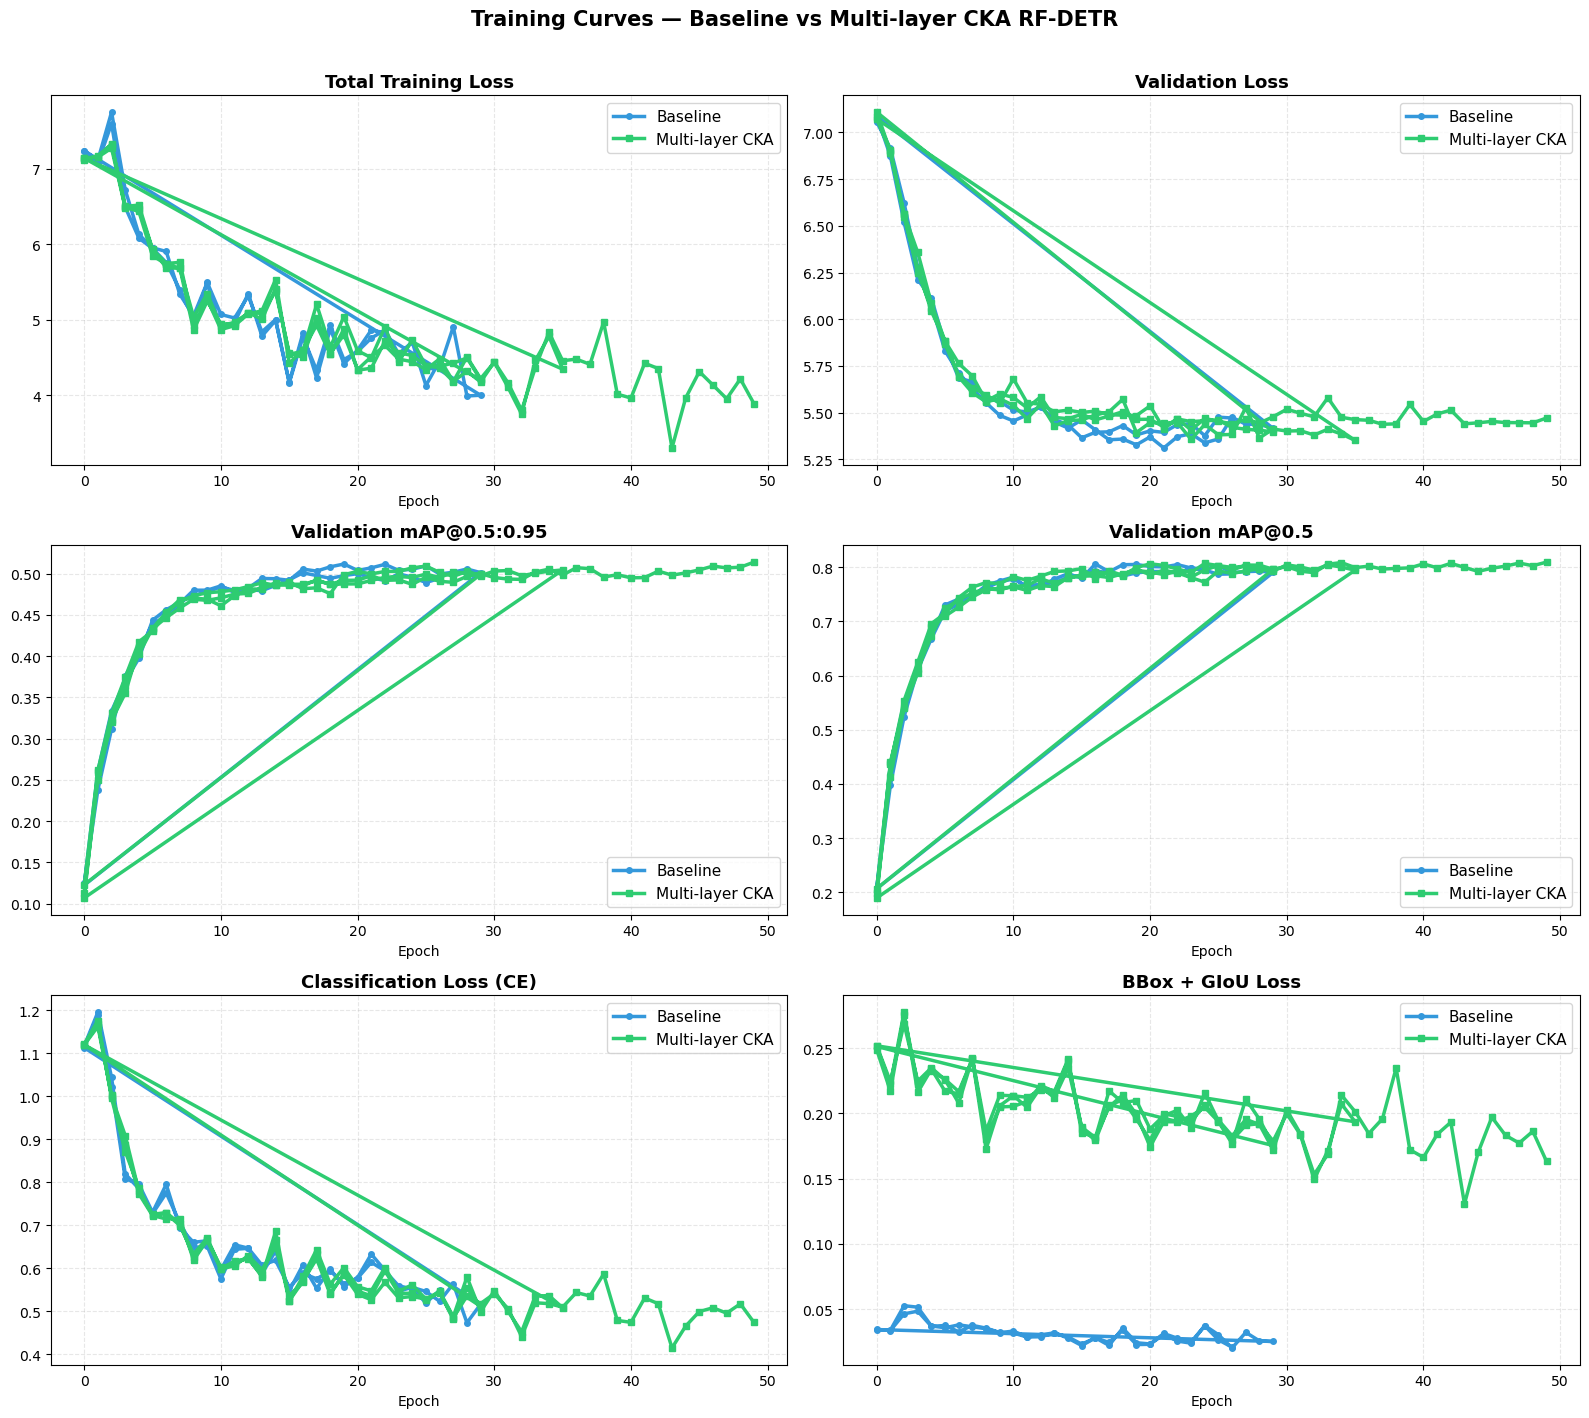

✓ Saved → output\training_curves.png


In [32]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
panels = [
    ("Total Training Loss",       "train_loss",              "train_loss",              True),
    ("Validation Loss",           "test_loss",               "test_loss",               True),
    ("Validation mAP@0.5:0.95",   "test_coco_map",           "test_coco_map",           False),
    ("Validation mAP@0.5",        "test_coco_map50",         "test_coco_map50",         False),
    ("Classification Loss (CE)",  "train_loss_ce_unscaled",  "train_loss_ce_unscaled",  True),
    ("BBox + GIoU Loss",          "train_loss_bbox_unscaled","train_loss_giou_unscaled", True),
]

for ax, (title, b_key, m_key, lower_is_better) in zip(axes.flatten(), panels):
    ax.plot(log_b["epoch"], log_b[b_key], label="Baseline",
            color="#3498db", linewidth=2.5, marker="o", markersize=4)
    ax.plot(log_m["epoch"], log_m[m_key], label="Multi-layer CKA",
            color="#2ecc71", linewidth=2.5, marker="s", markersize=4)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper right" if lower_is_better else "lower right", fontsize=11)
    ax.grid(True, alpha=0.3, linestyle="--")

fig.suptitle("Training Curves — Baseline vs Multi-layer CKA RF-DETR",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
path = OUTPUT_DIR / "training_curves.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved → {path}")


In [33]:
def _best(arr): ep = int(np.argmax(arr)); return arr[ep], ep
def _worst(arr): ep = int(np.argmin(arr)); return arr[ep], ep

b_map,    b_map_ep    = _best(log_b["test_coco_map"])
m_map,    m_map_ep    = _best(log_m["test_coco_map"])
b_map50,  b_map50_ep  = _best(log_b["test_coco_map50"])
m_map50,  m_map50_ep  = _best(log_m["test_coco_map50"])
b_loss,   b_loss_ep   = _worst(log_b["test_loss"])
m_loss,   m_loss_ep   = _worst(log_m["test_loss"])

df_train = pd.DataFrame([
    ("Best mAP@0.5:0.95",
     f"{b_map:.4f} (ep {b_map_ep})", f"{m_map:.4f} (ep {m_map_ep})",   f"{m_map-b_map:+.4f}"),
    ("Best mAP@0.5",
     f"{b_map50:.4f} (ep {b_map50_ep})", f"{m_map50:.4f} (ep {m_map50_ep})", f"{m_map50-b_map50:+.4f}"),
    ("Best Val Loss",
     f"{b_loss:.4f} (ep {b_loss_ep})", f"{m_loss:.4f} (ep {m_loss_ep})",   f"{b_loss-m_loss:+.4f}"),
], columns=["Metric", "Baseline", "Multi-layer CKA", "Δ"])

print("\nTraining Summary")
print("-" * 70)
print(df_train.to_string(index=False))
df_train.to_csv(OUTPUT_DIR / "training_summary.csv", index=False)
print(f"\n✓ Saved → {OUTPUT_DIR / 'training_summary.csv'}")



Training Summary
----------------------------------------------------------------------
           Metric       Baseline Multi-layer CKA       Δ
Best mAP@0.5:0.95 0.5116 (ep 19) 0.5139 (ep 115) +0.0023
     Best mAP@0.5 0.8061 (ep 16) 0.8095 (ep 115) +0.0034
    Best Val Loss 5.3105 (ep 21)  5.3508 (ep 65) -0.0403

✓ Saved → output\training_summary.csv


# CKA LOSS DIAGNOSTIC

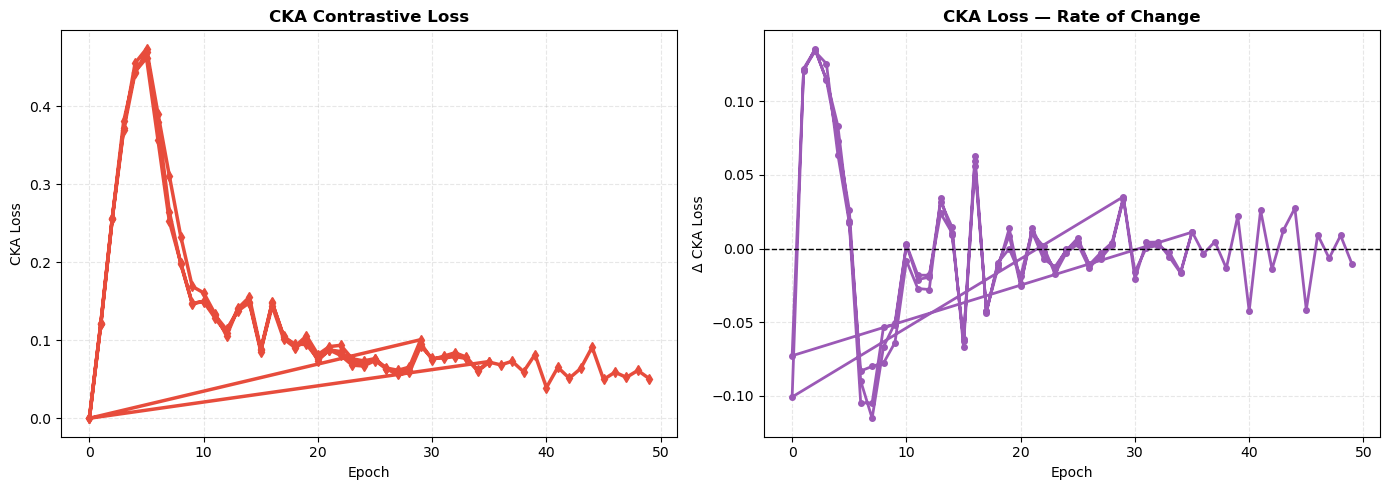

  Initial CKA loss : 0.000000
  Final CKA loss   : 0.050792
  Min CKA loss     : 0.000000  (epoch 0)

✓ Saved → output\cka_loss_analysis.png


In [34]:
cka_candidates = [
    "train_loss_cka_unscaled", "train_loss_cka",
    "loss_cka", "cka_loss", "train_cka_loss",
]
epochs, cka_losses = [], []

with open(MULTILAYER_LOG) as f:
    for line in f:
        try:
            row = json.loads(line.strip())
        except json.JSONDecodeError:
            continue
        for key in cka_candidates:
            if key in row:
                epochs.append(row.get("epoch", 0))
                cka_losses.append(row[key])
                break

if not cka_losses:
    print("⚠  No CKA loss key found in log.")
    print("   Check that cka_lambda > 0 during training.")
    print(f"   Expected one of: {cka_candidates}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, cka_losses, color="#e74c3c", linewidth=2.5,
                 marker="d", markersize=5)
    axes[0].set_title("CKA Contrastive Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("CKA Loss")
    axes[0].grid(True, alpha=0.3, linestyle="--")

    if len(cka_losses) > 1:
        deltas = np.diff(cka_losses).tolist()
        axes[1].plot(epochs[1:], deltas, color="#9b59b6", linewidth=2,
                     marker="o", markersize=4)
        axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
        axes[1].set_title("CKA Loss — Rate of Change", fontweight="bold")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Δ CKA Loss")
        axes[1].grid(True, alpha=0.3, linestyle="--")

    plt.tight_layout()
    path = OUTPUT_DIR / "cka_loss_analysis.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"  Initial CKA loss : {cka_losses[0]:.6f}")
    print(f"  Final CKA loss   : {cka_losses[-1]:.6f}")
    min_val = min(cka_losses)
    print(f"  Min CKA loss     : {min_val:.6f}  (epoch {epochs[cka_losses.index(min_val)]})")
    print(f"\n✓ Saved → {path}")
